In [15]:
# Cell 1 — Configuration & Parameters

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# ── Periods ───────────────────────────────────────────────────────────────────
IS_START  = '2018-01-01'
IS_END    = '2022-12-31'
OOS_START = '2023-01-01'
OOS_END   = '2025-12-31'

# ── Portfolio Parameters ──────────────────────────────────────────────────────
TOP_N          = 3
SAFE_HAVEN     = 'GLD'
REBALANCE_FREQ = 'W-FRI'
RSI_PERIOD     = 14
RSI_THRESHOLD  = 50

# ── Transaction Cost Model ────────────────────────────────────────────────────
CRYPTO_TICKERS         = {'BTC-USD', 'ETH-USD', 'SOL-USD', 'BNB-USD'}
TQQQ_DECAY_BPS_PER_DAY = 0.7 / 10_000

def one_way_cost(ticker: str) -> float:
    if ticker in CRYPTO_TICKERS:
        return 0.0030
    return 0.0011

# ── Best ensemble logic per asset ─────────────────────────────────────────────
BEST_LOGIC = {
    'GLD':     ('MAJORITY', 'OR'),
    'SPY':     ('OR',       'OR'),
    'QQQ':     ('MAJORITY', 'MAJORITY'),
    'TQQQ':    ('AND',      'AND'),
    'BTC-USD': ('AND',      'OR'),
    'SOL-USD': ('AND',      'OR'),
    'ETH-USD': ('OR',       'OR'),
    'BNB-USD': ('MAJORITY', 'OR'),
    'MSFT':    ('OR',       'OR'),
    'AAPL':    ('MAJORITY', 'MAJORITY'),
    'NVDA':    ('OR',       'OR'),
    'SMH':     ('MAJORITY', 'MAJORITY'),
    'BBH':     ('OR',  'AND'),
    'CTA':     ('OR',  'AND'),
    'IRBO':    ('OR',  'OR'),
    'LIT':     ('OR',  'OR'),
    'MOTI':    ('OR', 'OR'),
    'REMX':    ('OR',  'AND'),
    'SNSR':    ('OR',  'AND'),
    'VLUE':    ('OR',  'OR'),
    'WCLD':    ('OR',  'AND'),
    'WTV':     ('OR',  'OR'),
}

TICKERS = list(BEST_LOGIC.keys())

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        10,
})

print('Parameters defined ✓')
print(f'Universe : {TICKERS}')
print(f'TOP_N={TOP_N}  SAFE_HAVEN={SAFE_HAVEN}  RSI_PERIOD={RSI_PERIOD}  RSI_THRESHOLD={RSI_THRESHOLD}')
print('\nTransaction cost model:')
for t in TICKERS:
    note = ' + 0.7 bp/day holding decay' if t == 'TQQQ' else ''
    print(f'  {t:<10}: {one_way_cost(t)*10_000:.0f} bps one-way{note}')

Parameters defined ✓
Universe : ['GLD', 'SPY', 'QQQ', 'TQQQ', 'BTC-USD', 'SOL-USD', 'ETH-USD', 'BNB-USD', 'MSFT', 'AAPL', 'NVDA', 'SMH', 'BBH', 'CTA', 'IRBO', 'LIT', 'MOTI', 'REMX', 'SNSR', 'VLUE', 'WCLD', 'WTV']
TOP_N=3  SAFE_HAVEN=GLD  RSI_PERIOD=14  RSI_THRESHOLD=50

Transaction cost model:
  GLD       : 11 bps one-way
  SPY       : 11 bps one-way
  QQQ       : 11 bps one-way
  TQQQ      : 11 bps one-way + 0.7 bp/day holding decay
  BTC-USD   : 30 bps one-way
  SOL-USD   : 30 bps one-way
  ETH-USD   : 30 bps one-way
  BNB-USD   : 30 bps one-way
  MSFT      : 11 bps one-way
  AAPL      : 11 bps one-way
  NVDA      : 11 bps one-way
  SMH       : 11 bps one-way
  BBH       : 11 bps one-way
  CTA       : 11 bps one-way
  IRBO      : 11 bps one-way
  LIT       : 11 bps one-way
  MOTI      : 11 bps one-way
  REMX      : 11 bps one-way
  SNSR      : 11 bps one-way
  VLUE      : 11 bps one-way
  WCLD      : 11 bps one-way
  WTV       : 11 bps one-way


In [16]:
# Cell 2 — Data Download & Parsing
raw = yf.download(TICKERS, start='2017-01-01', end=OOS_END, auto_adjust=True)

price_data = {}
for ticker in TICKERS:
    try:
        df = pd.DataFrame({
            'Open':   raw['Open'][ticker],
            'High':   raw['High'][ticker],
            'Low':    raw['Low'][ticker],
            'Close':  raw['Close'][ticker],
            'Volume': raw['Volume'][ticker],
        }).dropna()
        price_data[ticker] = df
        print(f'  {ticker}: {len(df)} bars  ({df.index[0].date()} → {df.index[-1].date()})')
    except Exception as e:
        print(f'  {ticker}: FAILED — {e}')

print(f'\nLoaded {len(price_data)} tickers ✓')

# ── OPTION C: Build the merged full calendar ───────────────────────────────────
# Union of all trading days across equity and crypto.
# Equity assets trade ~252 days/yr; crypto trades 365 days/yr.
# The merged index contains every day that ANY asset has a price.
# Equity returns will be 0 on non-trading days (correct: markets closed).
# Crypto returns will reflect actual weekend moves (correct: they trade).

all_native_indices = [df.index for df in price_data.values()]
FULL_INDEX = all_native_indices[0]
for idx in all_native_indices[1:]:
    FULL_INDEX = FULL_INDEX.union(idx)
FULL_INDEX = FULL_INDEX.sort_values()

# Equity-only days kept available for diagnostics
equity_tickers_list = [t for t in TICKERS if t not in CRYPTO_TICKERS and t in price_data]
_equity_union = price_data[equity_tickers_list[0]].index
for t in equity_tickers_list[1:]:
    _equity_union = _equity_union.union(price_data[t].index)
EQUITY_TRADING_DAYS = _equity_union.sort_values()

print(f'\nFULL_INDEX  : {len(FULL_INDEX)} days  '
      f'({FULL_INDEX[0].date()} → {FULL_INDEX[-1].date()})')
print(f'Equity days : {len(EQUITY_TRADING_DAYS)} days')
print(f'Extra crypto days (weekends/holidays): '
      f'{len(FULL_INDEX) - len(EQUITY_TRADING_DAYS)}')

[*********************100%***********************]  22 of 22 completed

  GLD: 2261 bars  (2017-01-03 → 2025-12-30)
  SPY: 2261 bars  (2017-01-03 → 2025-12-30)
  QQQ: 2261 bars  (2017-01-03 → 2025-12-30)
  TQQQ: 2261 bars  (2017-01-03 → 2025-12-30)
  BTC-USD: 3286 bars  (2017-01-01 → 2025-12-30)
  SOL-USD: 2091 bars  (2020-04-10 → 2025-12-30)
  ETH-USD: 2974 bars  (2017-11-09 → 2025-12-30)
  BNB-USD: 2974 bars  (2017-11-09 → 2025-12-30)
  MSFT: 2261 bars  (2017-01-03 → 2025-12-30)
  AAPL: 2261 bars  (2017-01-03 → 2025-12-30)
  NVDA: 2261 bars  (2017-01-03 → 2025-12-30)
  SMH: 2261 bars  (2017-01-03 → 2025-12-30)
  BBH: 2261 bars  (2017-01-03 → 2025-12-30)
  CTA: 958 bars  (2022-03-08 → 2025-12-30)
  IRBO: 1888 bars  (2018-06-26 → 2025-12-30)
  LIT: 2261 bars  (2017-01-03 → 2025-12-30)
  MOTI: 2261 bars  (2017-01-03 → 2025-12-30)
  REMX: 2261 bars  (2017-01-03 → 2025-12-30)
  SNSR: 2261 bars  (2017-01-03 → 2025-12-30)
  VLUE: 2261 bars  (2017-01-03 → 2025-12-30)
  WCLD: 1588 bars  (2019-09-06 → 2025-12-30)
  WTV: 2261 bars  (2017-01-03 → 2025-12-30)

Loaded

In [17]:
# Cell 3 — Calendar Construction (Option C)
# All signals end with .shift(1) as their final operation.
# Indicators are computed on each asset's native price series
# so no calendar distortion occurs here.

def compute_atr(high, low, close, period):
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs(),
    ], axis=1).max(axis=1)
    atr = np.full(len(tr), np.nan)
    atr[period - 1] = tr.iloc[:period].mean()
    alpha = 1.0 / period
    for i in range(period, len(tr)):
        atr[i] = atr[i-1] * (1 - alpha) + tr.iloc[i] * alpha
    return pd.Series(atr, index=close.index)


def supertrend_signal(high, low, close, atr_period, multiplier):
    hl2 = (high + low) / 2.0
    atr = compute_atr(high, low, close, atr_period)
    basic_upper = hl2 + multiplier * atr
    basic_lower = hl2 - multiplier * atr
    n  = len(close)
    fu = np.full(n, np.nan)
    fl = np.full(n, np.nan)
    direction = np.full(n, np.nan)
    c  = close.values
    bu = basic_upper.values
    bl = basic_lower.values
    seed = atr_period
    fu[seed] = bu[seed]
    fl[seed] = bl[seed]
    direction[seed] = 1 if c[seed] > bu[seed] else -1
    for i in range(seed + 1, n):
        if np.isnan(bu[i]):
            continue
        fu[i] = bu[i] if (bu[i] < fu[i-1] or c[i-1] > fu[i-1]) else fu[i-1]
        fl[i] = bl[i] if (bl[i] > fl[i-1] or c[i-1] < fl[i-1]) else fl[i-1]
        if   c[i] > fu[i-1]: direction[i] =  1
        elif c[i] < fl[i-1]: direction[i] = -1
        else:                 direction[i] = direction[i-1]
    raw_signal = (pd.Series(direction, index=close.index) == 1).astype(int)
    return raw_signal.shift(1).fillna(0).astype(int)


def kama_signal(close, er_period, fast_period, slow_period):
    fast_sc = 2 / (fast_period + 1)
    slow_sc = 2 / (slow_period + 1)
    c = close.values
    n = len(c)
    kama = np.full(n, np.nan)
    kama[er_period - 1] = c[er_period - 1]
    for i in range(er_period, n):
        direction_  = abs(c[i] - c[i - er_period])
        volatility  = np.sum(np.abs(np.diff(c[i - er_period: i + 1])))
        er = direction_ / volatility if volatility != 0 else 0
        sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
        kama[i] = kama[i-1] + sc * (c[i] - kama[i-1])
    kama_s   = pd.Series(kama, index=close.index)
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, n):
        if pd.isna(kama_s.iloc[i-1]):
            continue
        if state == 0:
            if close.iloc[i] > kama_s.iloc[i-1]: state = 1
        else:
            if close.iloc[i] < kama_s.iloc[i-1]: state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


def rsi_window_signal(close, rsi_period, window):
    delta    = close.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    rsi      = 100 - (100 / (1 + rs))
    upper    = rsi.rolling(window).quantile(0.80)
    lower    = rsi.rolling(window).quantile(0.20)
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(rsi)):
        up = upper.iloc[i-1]
        lo = lower.iloc[i-1]
        if pd.isna(up) or pd.isna(lo):
            position.iloc[i] = state
            continue
        if state == 0:
            if rsi.iloc[i] > up: state = 1
        else:
            if rsi.iloc[i] < lo: state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


def triple_ema_signal(close, fast, medium, slow):
    ef = close.ewm(span=fast,   adjust=False).mean()
    em = close.ewm(span=medium, adjust=False).mean()
    es = close.ewm(span=slow,   adjust=False).mean()
    bullish = ((ef > em) & (em > es)).astype(int)
    return bullish.shift(1).fillna(0).astype(int)


def macd_signal(close, fast, slow, signal):
    ema_fast    = close.ewm(span=fast,   adjust=False).mean()
    ema_slow    = close.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    raw = (macd_line > signal_line).astype(int)
    return raw.shift(1).fillna(0).astype(int)


def donchian_signal(close, high, low, entry_period, exit_period):
    upper_entry = high.rolling(entry_period).max()
    lower_exit  = low.rolling(exit_period).min()
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(close)):
        if state == 0:
            if close.iloc[i] > upper_entry.iloc[i-1]: state = 1
        else:
            if close.iloc[i] < lower_exit.iloc[i-1]:  state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


def bollinger_signal(close, period, mult):
    middle = close.rolling(window=period).mean()
    std    = close.rolling(window=period).std(ddof=0)
    lower  = middle - mult * std
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(close)):
        if pd.isna(lower.iloc[i-1]):
            continue
        if state == 0:
            if close.iloc[i-1] > lower.iloc[i-1] and close.iloc[i] <= lower.iloc[i]:
                state = 1
        else:
            if close.iloc[i-1] < middle.iloc[i-1] and close.iloc[i] >= middle.iloc[i]:
                state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


print('Indicator library defined ✓  (all signals end with .shift(1))')

Indicator library defined ✓  (all signals end with .shift(1))


In [18]:
# Cell 4 — Indicator Library

def build_signals(ticker, df):
    c, h, l = df['Close'], df['High'], df['Low']
    configs = {
        'GLD':     [('MACD(75,226,150)',  lambda: macd_signal(c, 75, 226, 150)),
                    ('3EMA(56,91,116)',   lambda: triple_ema_signal(c, 56, 91, 116)),
                    ('KAMA(49,10,55)',    lambda: kama_signal(c, 49, 10, 55))],
        'SPY':     [('3EMA(6,11,26)',     lambda: triple_ema_signal(c, 6, 11, 26)),
                    ('KAMA(29,2,15)',     lambda: kama_signal(c, 29, 2, 15))],
        'QQQ':     [('MACD(190,266,190)', lambda: macd_signal(c, 190, 266, 190)),
                    ('ST(22,1.5)',        lambda: supertrend_signal(h, l, c, 22, 1.5)),
                    ('KAMA(43,10,20)',    lambda: kama_signal(c, 43, 10, 20))],
        'TQQQ':    [('ST(26,2.5)',        lambda: supertrend_signal(h, l, c, 26, 2.5))],
        'BTC-USD': [('RSI_W(5,165)',      lambda: rsi_window_signal(c, 5, 165)),
                    ('KAMA(7,10,20)',     lambda: kama_signal(c, 7, 10, 20))],
        'SOL-USD': [('RSI_W(28,35)',      lambda: rsi_window_signal(c, 28, 35)),
                    ('MACD(10,21,50)',    lambda: macd_signal(c, 10, 21, 50))],
        'ETH-USD': [('3EMA(6,11,21)',     lambda: triple_ema_signal(c, 6, 11, 21)),
                    ('RSI_W(10,65)',      lambda: rsi_window_signal(c, 10, 65))],
        'MSFT':    [('ST(24,6.0)',        lambda: supertrend_signal(h, l, c, 24, 6.0)),
                    ('KAMA(57,4,60)',     lambda: kama_signal(c, 57, 4, 60))],
        'AAPL':    [('BB(45,0.5)',        lambda: bollinger_signal(c, 45, 0.5)),
                    ('ST(10,2.0)',        lambda: supertrend_signal(h, l, c, 10, 2.0)),
                    ('KAMA(27,2,60)',     lambda: kama_signal(c, 27, 2, 60))],
        'BNB-USD': [('MACD(5,246,43)',    lambda: macd_signal(c, 5, 246, 43)),
                    ('DON(30,17)',        lambda: donchian_signal(c, h, l, 30, 17)),
                    ('ST(8,4.0)',         lambda: supertrend_signal(h, l, c, 8, 4.0))],
        'NVDA':    [('3EMA(46,61,146)',   lambda: triple_ema_signal(c, 46, 61, 146)),
                    ('MACD(210,241,195)', lambda: macd_signal(c, 210, 241, 195))],
        'SMH':     [('KAMA(27,16,25)',    lambda: kama_signal(c, 27, 16, 25)),
                    ('3EMA(86,121,206)',  lambda: triple_ema_signal(c, 86, 121, 206)),
                    ('MACD(17,261,255)',  lambda: macd_signal(c, 17, 261, 255))],
        'BBH':     [('BB(33,2.5)',        lambda: bollinger_signal(c, 33, 2.5)),
                    ('RSI_W(4,10)',       lambda: rsi_window_signal(c, 4, 10))],
        'CTA':     [('BB(10,0.5)',        lambda: bollinger_signal(c, 10, 0.5)),
                    ('RSI_W(8,15)',       lambda: rsi_window_signal(c, 8, 15))],
        'IRBO':    [('KAMA(41,4,35)',     lambda: kama_signal(c, 41, 4, 35)),
                    ('ST(30,6.0)',        lambda: supertrend_signal(h, l, c, 30, 6.0))],
        'LIT':     [('DON(55,25)',        lambda: donchian_signal(c, h, l, 55, 25)),
                    ('KAMA(19,2,10)',     lambda: kama_signal(c, 19, 2, 10))],
        'MOTI':    [('MACD(5,81,5)',      lambda: macd_signal(c, 5, 81, 5)),
                    ('RSI_W(2,85)',       lambda: rsi_window_signal(c, 2, 85))],
        'REMX':    [('ST(6,1.5)',         lambda: supertrend_signal(h, l, c, 6, 1.5)),
                    ('MACD(5,296,7)',     lambda: macd_signal(c, 5, 296, 7))],
        'SNSR':    [('MACD(5,46,5)',      lambda: macd_signal(c, 5, 46, 5)),
                    ('BB(19,2.5)',        lambda: bollinger_signal(c, 19, 2.5))],
        'VLUE':    [('RSI_W(2,45)',       lambda: rsi_window_signal(c, 2, 45)),
                    ('MACD(5,16,5)',      lambda: macd_signal(c, 5, 16, 5))],
        'WCLD':    [('RSI_W(3,140)',      lambda: rsi_window_signal(c, 3, 140)),
                    ('BB(20,2.0)',        lambda: bollinger_signal(c, 20, 2.0))],
        'WTV':     [('ST(28,4.0)',        lambda: supertrend_signal(h, l, c, 28, 4.0)),
                    ('KAMA(13,2,10)',     lambda: kama_signal(c, 13, 2, 10))],
    }
    if ticker not in configs:
        return {}
    signals = {}
    for label, fn in configs[ticker]:
        try:
            signals[label] = fn()
        except Exception as e:
            print(f'  Warning: {ticker} {label} failed — {e}')
    return signals


def apply_logic(signals_arr, mode):
    n = len(signals_arr)
    if mode == 'AND':
        return all(s == 1 for s in signals_arr)
    elif mode == 'OR':
        return any(s == 1 for s in signals_arr)
    elif mode == 'MAJORITY':
        return any(s == 1 for s in signals_arr) if n <= 2 \
               else sum(s == 1 for s in signals_arr) > n / 2
    return False


def run_ensemble(signal_dict, entry_logic, exit_logic):
    labels = list(signal_dict.keys())
    n_ind  = len(labels)
    if n_ind == 0:
        raise ValueError('No signals provided')
    if n_ind == 1:
        return list(signal_dict.values())[0]

    sig_df = pd.DataFrame(signal_dict).fillna(0).astype(int)
    pos    = pd.Series(0, index=sig_df.index, dtype=int)
    state  = 0
    for i in range(len(sig_df)):
        row = sig_df.iloc[i].values
        if state == 0:
            if apply_logic(row, entry_logic): state = 1
        else:
            exit_row = [1 - s for s in row]
            if apply_logic(exit_row, exit_logic): state = 0
        pos.iloc[i] = state
    return pos


print('Signal configs & ensemble engine defined ✓')

Signal configs & ensemble engine defined ✓


In [ ]:
# Cell 5 — Signal Configs & Ensemble Engine
# OPTION C CHANGE:
# After computing the position on the asset's native calendar, reindex to
# FULL_INDEX and forward-fill. Equity positions on Sat/Sun carry Friday's
# signal unchanged — markets are closed, no new information. Crypto positions
# are already on a 365-day calendar so ffill is a no-op for them.

print('Building ensemble positions for all assets...')

all_positions = {}
all_closes    = {}

for ticker in TICKERS:
    if ticker not in price_data:
        print(f'  {ticker}: no price data — skipping')
        continue
    df           = price_data[ticker]
    entry, exit_ = BEST_LOGIC[ticker]
    sigs         = build_signals(ticker, df)
    if not sigs:
        print(f'  {ticker}: no signals built — skipping')
        continue
    pos = run_ensemble(sigs, entry, exit_)

    # Reindex to the merged full calendar and forward-fill held positions.
    # ffill() propagates Friday's signal through Saturday and Sunday for
    # equity assets; fillna(0) handles the pre-warmup period.
    pos_full = pos.reindex(FULL_INDEX).ffill().fillna(0).astype(int)
    all_positions[ticker] = pos_full

    # Close series: reindex to FULL_INDEX and ffill.
    # Equity closes are flat over weekends (correct — no trading).
    # Crypto closes are real every day.
    all_closes[ticker] = price_data[ticker]['Close'].reindex(FULL_INDEX).ffill()

    print(f'  {ticker}: done  (entry={entry}, exit={exit_}, '
          f'full_index bars={len(pos_full)})')

print(f'\nPositions built for {len(all_positions)} assets ✓')

Building ensemble positions for all assets...
  GLD: done  (entry=MAJORITY, exit=OR, full_index bars=3286)
  SPY: done  (entry=OR, exit=OR, full_index bars=3286)
  QQQ: done  (entry=MAJORITY, exit=MAJORITY, full_index bars=3286)
  TQQQ: done  (entry=AND, exit=AND, full_index bars=3286)
  BTC-USD: done  (entry=AND, exit=OR, full_index bars=3286)
  SOL-USD: done  (entry=AND, exit=OR, full_index bars=3286)
  ETH-USD: done  (entry=OR, exit=OR, full_index bars=3286)
  BNB-USD: done  (entry=MAJORITY, exit=OR, full_index bars=3286)
  MSFT: done  (entry=OR, exit=OR, full_index bars=3286)
  AAPL: done  (entry=MAJORITY, exit=MAJORITY, full_index bars=3286)
  NVDA: done  (entry=OR, exit=OR, full_index bars=3286)
  SMH: done  (entry=MAJORITY, exit=MAJORITY, full_index bars=3286)
  BBH: done  (entry=OR, exit=AND, full_index bars=3286)
  CTA: done  (entry=OR, exit=AND, full_index bars=3286)
  IRBO: done  (entry=OR, exit=OR, full_index bars=3286)
  LIT: done  (entry=OR, exit=OR, full_index bars=3286)

In [ ]:
# Cell 6 — Position Building
# OPTION C CHANGE:
# Removed the equity_day_mask that previously dropped weekend rows.
# Cumulative returns are now built on FULL_INDEX. Because all_closes values
# are already ffill'd, pct_change() on equity assets returns 0 on weekends —
# no phantom returns. Crypto returns are real every day. The RSI lag shift
# is retained. On weekends, equity RSI is unchanged (flat price → no update),
# which is correct — no new signal should fire on a closed market.

def compute_rsi_series(series, period):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def build_rsi_ranks(all_closes, period, threshold):
    cum_rets = {}
    for ticker, close in all_closes.items():
        daily = close.pct_change().fillna(0)
        cum_rets[ticker] = (1 + daily).cumprod()

    cum_df = pd.DataFrame(cum_rets)

    rsi_df = pd.DataFrame({
        ticker: compute_rsi_series(cum_df[ticker], period)
        for ticker in cum_df.columns
    })

    rsi_lagged = rsi_df.shift(1)  # today's rank uses yesterday's RSI

    ranks = pd.DataFrame(index=rsi_lagged.index,
                         columns=rsi_lagged.columns, dtype=float)
    for date in rsi_lagged.index:
        row      = rsi_lagged.loc[date]
        eligible = row[row >= threshold]
        if eligible.empty:
            ranks.loc[date] = np.nan
        else:
            ranked = eligible.rank(ascending=False, method='first')
            ranks.loc[date, ranked.index] = ranked.values

    return ranks, rsi_lagged


print('Building RSI momentum ranks on merged full calendar...')
rsi_ranks, rsi_values = build_rsi_ranks(all_closes, RSI_PERIOD, RSI_THRESHOLD)
print(f'RSI ranks built: {rsi_ranks.shape[0]} dates × {rsi_ranks.shape[1]} assets ✓')
print('\nSample ranks (last 5 rows):')
display(rsi_ranks.tail())

Building RSI momentum ranks on merged full calendar...
RSI ranks built: 3286 dates × 22 assets ✓

Sample ranks (last 5 rows):


,GLD,SPY,QQQ,TQQQ,BTC-USD,SOL-USD,ETH-USD,BNB-USD,MSFT,AAPL,...,BBH,CTA,IRBO,LIT,MOTI,REMX,SNSR,VLUE,WCLD,WTV
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-26,1.0000,6.0000,9.0000,12.0000,NaN,NaN,NaN,NaN,16.0000,NaN,...,11.0000,7.0000,14.0000,2.0000,13.0000,3.0000,17.0000,4.0000,15.0000,5.0000
2025-12-27,1.0000,7.0000,11.0000,12.0000,NaN,NaN,NaN,NaN,16.0000,NaN,...,15.0000,3.0000,14.0000,2.0000,9.0000,4.0000,17.0000,5.0000,13.0000,6.0000
2025-12-28,1.0000,7.0000,11.0000,12.0000,NaN,NaN,NaN,NaN,16.0000,NaN,...,15.0000,3.0000,14.0000,2.0000,9.0000,4.0000,17.0000,5.0000,13.0000,6.0000
2025-12-29,1.0000,7.0000,11.0000,12.0000,NaN,NaN,NaN,NaN,16.0000,NaN,...,15.0000,3.0000,14.0000,2.0000,9.0000,4.0000,17.0000,5.0000,13.0000,6.0000
2025-12-30,NaN,3.0000,10.0000,12.0000,NaN,NaN,NaN,NaN,13.0000,NaN,...,14.0000,15.0000,6.0000,7.0000,9.0000,8.0000,NaN,1.0000,11.0000,2.0000


In [ ]:
# Cell 7 — Portfolio Weight Construction
# Unchanged in logic. Now operates on FULL_INDEX throughout.
# Fridays always exist in FULL_INDEX (crypto trades every day),
# so there is no "missing rebalance Friday" edge case.

def build_portfolio_weights(rsi_ranks, all_positions, all_closes,
                             top_n, safe_haven, tickers):
    common_idx = rsi_ranks.index   # = FULL_INDEX
    pos_df = pd.DataFrame({
        t: all_positions[t].reindex(common_idx, fill_value=0)
        for t in tickers if t in all_positions
    })
    rank_df = rsi_ranks.reindex(columns=pos_df.columns)

    weight_per_slot = 1.0 / top_n
    weights_df = pd.DataFrame(0.0, index=common_idx, columns=pos_df.columns)

    risk_universe = [t for t in pos_df.columns if t != safe_haven]

    for date in common_idx:
        ranks_today = rank_df.loc[date]
        pos_today   = pos_df.loc[date]

        top_ranked    = ranks_today[
            ranks_today.index.isin(risk_universe) & (ranks_today <= top_n)
        ].index.tolist()
        eligible_risk = [t for t in top_ranked if pos_today.get(t, 0) == 1]

        slots_filled = 0
        for asset in eligible_risk:
            weights_df.loc[date, asset] = weight_per_slot
            slots_filled += 1

        remaining = top_n - slots_filled
        if remaining > 0 and safe_haven in pos_df.columns:
            if pos_today.get(safe_haven, 0) == 1:
                weights_df.loc[date, safe_haven] = remaining * weight_per_slot

    row_sums = weights_df.sum(axis=1)
    assert row_sums.max() <= 1.0 + 1e-9, \
        f'Weight sum exceeded 1.0! Max = {row_sums.max():.6f}'

    return weights_df


print('Building portfolio weights...')
weights_df = build_portfolio_weights(
    rsi_ranks, all_positions, all_closes,
    TOP_N, SAFE_HAVEN, TICKERS
)

weight_sums = weights_df.sum(axis=1)
print(f'Weight sum stats  (max must be ≤ 1.000):')
print(f'  Mean : {weight_sums.mean():.3f}')
print(f'  Min  : {weight_sums.min():.3f}')
print(f'  Max  : {weight_sums.max():.3f}')
print(f'  % days fully invested : {(weight_sums >= 0.999).mean():.1%}')
print(f'  % days in cash        : {(weight_sums < 0.001).mean():.1%}')
print('\nPortfolio weights built ✓')

Building portfolio weights...
Weight sum stats  (max must be ≤ 1.000):
  Mean : 0.907
  Min  : 0.000
  Max  : 1.000
  % days fully invested : 83.5%
  % days in cash        : 3.5%

Portfolio weights built ✓


In [ ]:
# Cell 8 — Return & Cost Calculation
# OPTION C CHANGE:
# pct_change() on equity closes is 0 on weekends → equity contributes zero
# P&L on weekends (correct: markets closed). pct_change() on crypto closes
# is real on weekends → crypto contributes actual weekend P&L (correct: they
# trade). Weights on weekends equal Friday's weights (held over, no rebalance),
# so weight.diff() = 0 on Sat/Sun → no spurious transaction costs fire.
# TQQQ decay applies every calendar day it is held.

def build_portfolio_returns(weights_df, all_closes, crypto_tickers,
                             tqqq_decay_per_day):
    common_idx = weights_df.index
    ret_df = pd.DataFrame(index=common_idx, columns=weights_df.columns,
                          dtype=float)
    for ticker in weights_df.columns:
        if ticker in all_closes:
            ret_df[ticker] = all_closes[ticker].reindex(common_idx).pct_change()
    ret_df = ret_df.fillna(0.0)

    gross_ret = (weights_df * ret_df).sum(axis=1)

    # Transaction costs only fire when weights actually change.
    # On weekends weights are unchanged (ffill from Friday) → diff = 0 → no cost.
    weight_changes = weights_df.diff().abs()
    cost_series    = pd.Series(0.0, index=common_idx)
    for ticker in weights_df.columns:
        cost_series += weight_changes[ticker] * one_way_cost(ticker)

    if 'TQQQ' in weights_df.columns:
        cost_series += weights_df['TQQQ'] * tqqq_decay_per_day

    net_ret = gross_ret - cost_series
    return net_ret, gross_ret, cost_series, ret_df


print('Computing portfolio returns...')
net_ret, gross_ret, costs, ret_df = build_portfolio_returns(
    weights_df, all_closes, CRYPTO_TICKERS, TQQQ_DECAY_BPS_PER_DAY
)

is_mask  = (net_ret.index >= IS_START)  & (net_ret.index <= IS_END)
oos_mask = (net_ret.index >= OOS_START) & (net_ret.index <= OOS_END)

net_ret_is  = net_ret[is_mask]
net_ret_oos = net_ret[oos_mask]

equity_full = (1 + net_ret).cumprod()
equity_is   = (1 + net_ret_is).cumprod()
equity_oos  = (1 + net_ret_oos).cumprod()

print('Returns computed ✓')
print(f'  Total cost drag : {costs.sum():.2%} over full period')
print(f'  Avg daily cost  : {costs.mean()*10_000:.3f} bps/day')

Computing portfolio returns...
Returns computed ✓
  Total cost drag : 192.59% over full period
  Avg daily cost  : 5.863 bps/day


In [ ]:
# Cell 9: Define Metrics
# OPTION C CHANGE:
# Annualisation uses actual calendar-day span (len(returns) / years) rather
# than a hardcoded 252-period assumption. The merged index contains ~365 rows
# per year, so using 252 would understate annualised vol and overstate Sharpe.
# CAGR, Sharpe, and Calmar are all self-consistent under this convention.

def full_metrics(returns: pd.Series, equity: pd.Series, label=''):
    if len(returns) == 0 or len(equity) == 0:
        return pd.Series({'Label': label, 'CAGR': 0, 'Sharpe': 0,
                          'MaxDD': 0, 'Calmar': 0, 'WinRate': 0, 'Years': 0})
    years     = (equity.index[-1] - equity.index[0]).days / 365.25
    total_ret = equity.iloc[-1] / equity.iloc[0] - 1
    cagr      = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0.0

    actual_days_per_year = len(returns) / years if years > 0 else 365.25
    ret_ann  = returns.mean() * actual_days_per_year
    vol_ann  = returns.std()  * np.sqrt(actual_days_per_year)
    sharpe   = ret_ann / vol_ann if vol_ann > 0 else 0.0

    drawdown = equity / equity.cummax() - 1
    maxdd    = drawdown.min()
    calmar   = cagr / abs(maxdd) if maxdd < 0 else np.inf
    win_rate = (returns > 0).mean()
    return pd.Series({'Label': label, 'CAGR': cagr, 'Sharpe': sharpe,
                      'MaxDD': maxdd, 'Calmar': calmar,
                      'WinRate': win_rate, 'Years': years})

print('Metrics function defined ✓  (annualises by actual calendar days/year)')

Metrics function defined ✓  (annualises by actual calendar days/year)


In [ ]:
# Cell 10 — Performance Metrics
# OPTION C CHANGE:
# Removed equity_day_mask_is — no longer needed since the return series
# already correctly handles weekends (equity = 0, crypto = real).
# Max Sharpe and Max Omega are fit on the IS return DataFrame as-is.
# max_sharpe_portfolio annualises by actual days/year for consistency.

def max_sharpe_portfolio(ret_df, rf=0.04):
    years = (ret_df.index[-1] - ret_df.index[0]).days / 365.25
    adpy  = len(ret_df) / years if years > 0 else 365.25
    mu    = ret_df.mean() * adpy
    sigma = ret_df.cov()  * adpy
    n     = len(mu)
    def neg_sharpe(w):
        port_ret = w @ mu
        port_vol = np.sqrt(w @ sigma @ w)
        return -(port_ret - rf) / port_vol if port_vol > 0 else 0
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds      = [(0, 1)] * n
    result      = minimize(neg_sharpe, np.ones(n)/n, method='SLSQP',
                           bounds=bounds, constraints=constraints)
    return pd.Series(result.x, index=ret_df.columns)


def max_omega_portfolio(ret_df, threshold=0.0):
    n = ret_df.shape[1]
    def neg_omega(w):
        port_ret = ret_df @ w
        gains    = port_ret[port_ret > threshold] - threshold
        losses   = threshold - port_ret[port_ret <= threshold]
        return -(gains.sum() / losses.sum()) if losses.sum() != 0 else -1e9
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds      = [(0, 1)] * n
    result      = minimize(neg_omega, np.ones(n)/n, method='SLSQP',
                           bounds=bounds, constraints=constraints)
    return pd.Series(result.x, index=ret_df.columns)


is_ret_df  = ret_df[is_mask].copy()
oos_ret_df = ret_df[oos_mask].copy()

is_ret_df  = is_ret_df.loc[:, (is_ret_df != 0).any(axis=0)]
oos_ret_df = oos_ret_df.reindex(columns=is_ret_df.columns).fillna(0)

print('Optimising Max Sharpe portfolio...')
w_sharpe = max_sharpe_portfolio(is_ret_df)

print('Optimising Max Omega portfolio...')
w_omega  = max_omega_portfolio(is_ret_df)

def benchmark_equity(weights, ret_df):
    port_ret = ret_df @ weights
    return (1 + port_ret).cumprod(), port_ret

eq_sharpe_oos, ret_sharpe_oos = benchmark_equity(w_sharpe, oos_ret_df)
eq_omega_oos,  ret_omega_oos  = benchmark_equity(w_omega,  oos_ret_df)

sharpe_bm   = full_metrics(ret_sharpe_oos, eq_sharpe_oos, label='Max Sharpe BM (OOS)')
omega_bm    = full_metrics(ret_omega_oos,  eq_omega_oos,  label='Max Omega BM (OOS)')
oos_metrics = full_metrics(net_ret_oos, equity_oos,       label='Rotational Strategy (OOS)')

print('\n═══ Benchmark Comparison (OOS) ═══\n')
display(pd.DataFrame([oos_metrics, sharpe_bm, omega_bm]))

print('\n── Max Sharpe weights (IS-fitted) ──')
display(w_sharpe[w_sharpe > 0.01].sort_values(ascending=False).map('{:.1%}'.format))
print('\n── Max Omega weights (IS-fitted) ──')
display(w_omega[w_omega > 0.01].sort_values(ascending=False).map('{:.1%}'.format))

Optimising Max Sharpe portfolio...
Optimising Max Omega portfolio...

═══ Benchmark Comparison (OOS) ═══



,Label,CAGR,Sharpe,MaxDD,Calmar,WinRate,Years
0,Rotational Strategy (OOS),0.3429,1.3409,-0.2615,1.3115,0.3954,2.9952
1,Max Sharpe BM (OOS),0.5688,1.8653,-0.2471,2.3016,0.5416,2.9952
2,Max Omega BM (OOS),0.2078,1.7030,-0.0963,2.1566,0.5553,2.9952



── Max Sharpe weights (IS-fitted) ──


AAPL       29.2%
BNB-USD    21.1%
MSFT       21.1%
SOL-USD    15.0%
GLD        13.5%
dtype: object


── Max Omega weights (IS-fitted) ──


CTA        62.9%
GLD        16.1%
MSFT        8.1%
AAPL        6.2%
BNB-USD     3.4%
SOL-USD     3.1%
dtype: object

═══ Asset Correlation Matrix (IS, merged calendar) ═══



,GLD,SPY,QQQ,TQQQ,BTC-USD,SOL-USD,ETH-USD,BNB-USD,MSFT,AAPL,...,BBH,CTA,IRBO,LIT,MOTI,REMX,SNSR,VLUE,WCLD,WTV
GLD,1.0000,0.1100,0.1200,0.1200,0.1300,0.0900,0.1200,0.1100,0.0900,0.0800,...,0.0900,-0.3600,0.1400,0.1700,0.1600,0.1900,0.1300,0.0700,0.1700,0.0800
SPY,0.1100,1.0000,0.9300,0.9300,0.2700,0.2700,0.2800,0.2200,0.8500,0.8000,...,0.7300,-0.3300,0.8500,0.7000,0.8200,0.6500,0.8900,0.9300,0.6600,0.8900
QQQ,0.1200,0.9300,1.0000,1.0000,0.2800,0.2800,0.2900,0.2200,0.9100,0.8600,...,0.7600,-0.2900,0.8900,0.6800,0.7300,0.6200,0.8600,0.7900,0.7800,0.7400
TQQQ,0.1200,0.9300,1.0000,1.0000,0.2800,0.2800,0.2900,0.2200,0.9100,0.8700,...,0.7600,-0.2900,0.9000,0.6800,0.7300,0.6100,0.8600,0.7900,0.7900,0.7300
BTC-USD,0.1300,0.2700,0.2800,0.2800,1.0000,0.4600,0.8200,0.6400,0.2600,0.2300,...,0.2100,-0.2300,0.3300,0.2400,0.2600,0.2700,0.2800,0.2400,0.3600,0.2300
SOL-USD,0.0900,0.2700,0.2800,0.2800,0.4600,1.0000,0.5700,0.5000,0.2400,0.2500,...,0.1500,-0.1700,0.2700,0.2200,0.2200,0.2400,0.2800,0.2000,0.2200,0.2100
ETH-USD,0.1200,0.2800,0.2900,0.2900,0.8200,0.5700,1.0000,0.6400,0.2600,0.2400,...,0.2200,-0.1900,0.3300,0.2400,0.2600,0.2800,0.2900,0.2400,0.3300,0.2400
BNB-USD,0.1100,0.2200,0.2200,0.2200,0.6400,0.5000,0.6400,1.0000,0.2000,0.1900,...,0.1500,-0.1400,0.2800,0.1900,0.2100,0.2200,0.2300,0.2000,0.2700,0.1900
MSFT,0.0900,0.8500,0.9100,0.9100,0.2600,0.2400,0.2600,0.2000,1.0000,0.7700,...,0.6700,-0.2800,0.7700,0.5700,0.6200,0.5100,0.7400,0.6900,0.6800,0.6400
AAPL,0.0800,0.8000,0.8600,0.8700,0.2300,0.2500,0.2400,0.1900,0.7700,1.0000,...,0.5900,-0.2200,0.7300,0.5600,0.5900,0.4900,0.7200,0.6700,0.6100,0.6200


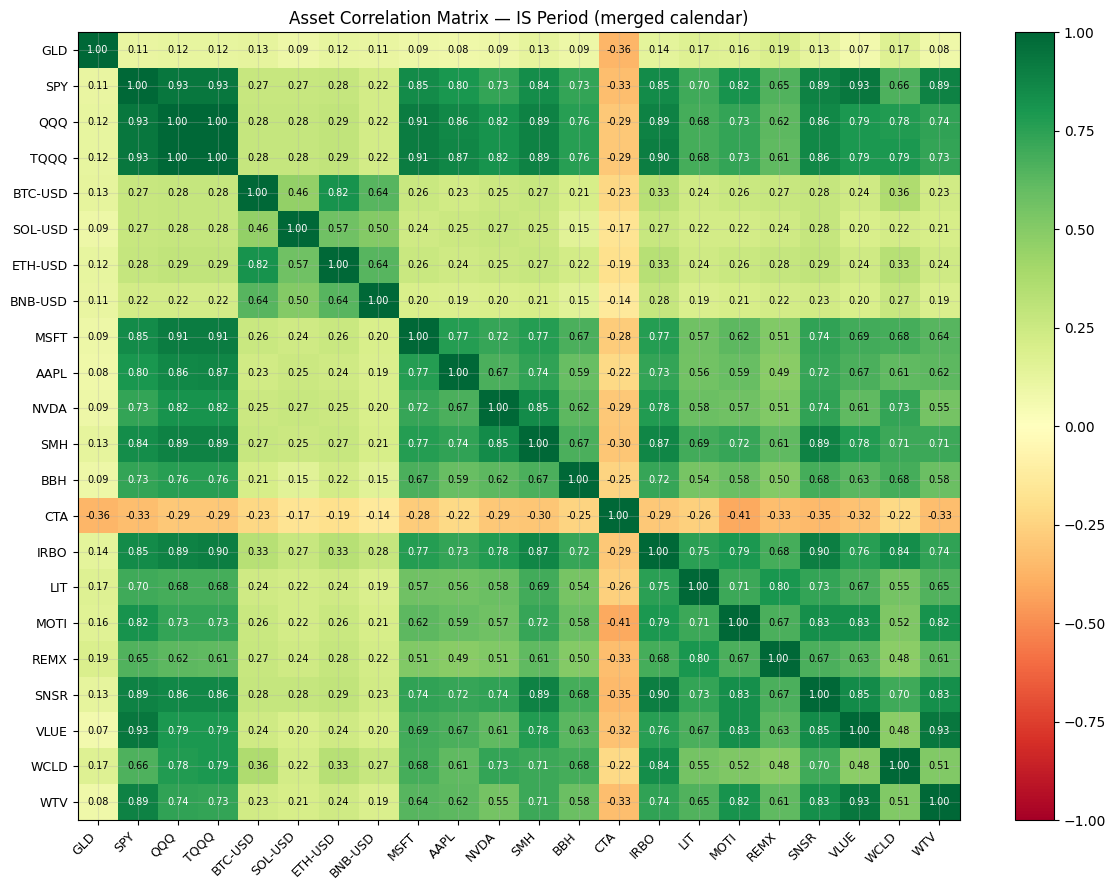

In [ ]:
# Cell 11 — Correlation Matrix
# OPTION C CHANGE:
# Removed equity_day_mask_corr. The merged calendar handles it correctly:
# equity weekend pct_change = 0, crypto = real. This slightly deflates
# equity annualised vol vs a pure 252-day series, but is the correct
# representation for the mixed-calendar universe.

print('═══ Asset Correlation Matrix (IS, merged calendar) ═══\n')

bnh_rets = pd.DataFrame({
    t: all_closes[t].reindex(FULL_INDEX).pct_change()
    for t in TICKERS if t in all_closes
})[is_mask]

corr = bnh_rets.corr().round(2)
display(corr)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='black' if abs(corr.iloc[i, j]) < 0.7 else 'white')
ax.set_title('Asset Correlation Matrix — IS Period (merged calendar)', fontsize=12)
plt.tight_layout()
plt.show()

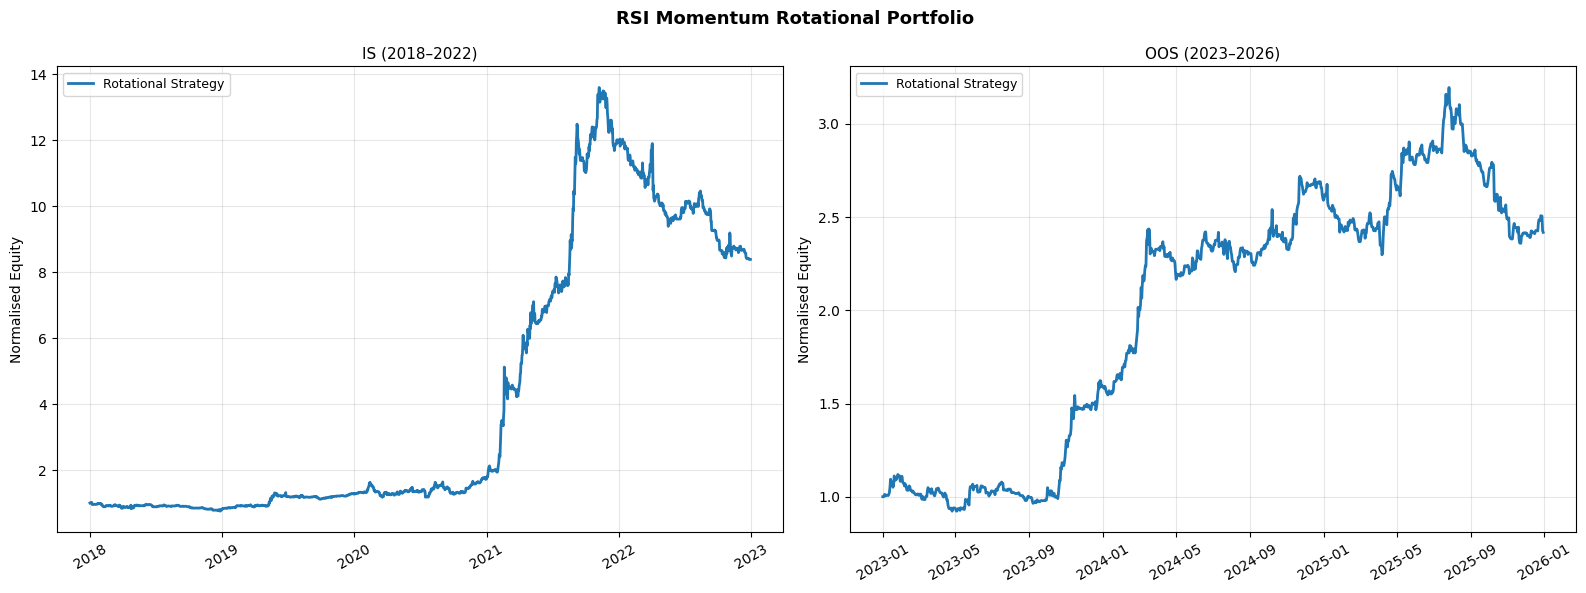

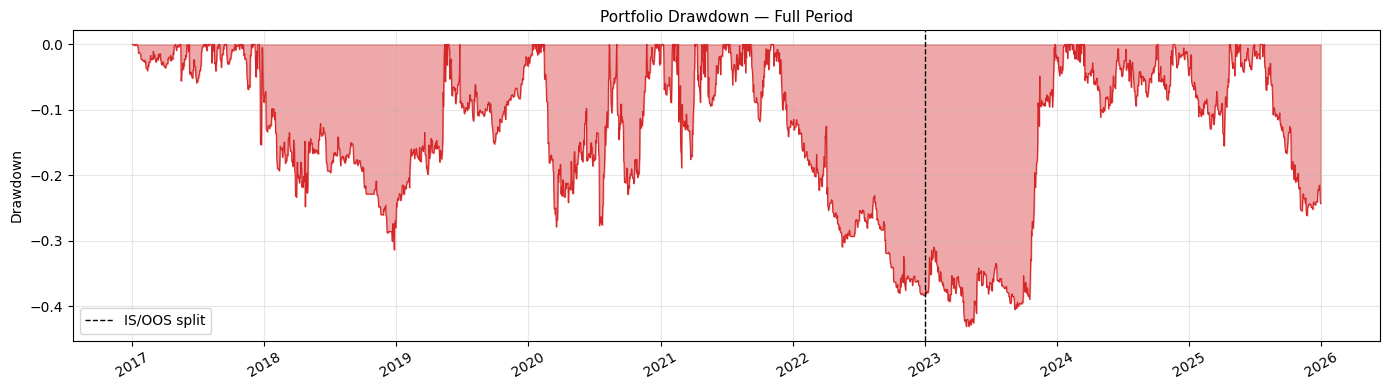

In [ ]:
# Cell 12 — Equity Curve & Drawdown Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RSI Momentum Rotational Portfolio', fontsize=13, fontweight='bold')

for ax, (phase, mask, net_r, eq) in zip(axes, [
    ('IS (2018–2022)',   is_mask,  net_ret_is,  equity_is),
    ('OOS (2023–2026)', oos_mask, net_ret_oos, equity_oos),
]):
    eq_n = eq / eq.iloc[0]
    ax.plot(eq_n.index, eq_n.values, color='#1f77b4',
            linewidth=2.0, label='Rotational Strategy')

    bh_colors = plt.cm.tab10(np.linspace(0, 1, len(TICKERS)))
    for i, t in enumerate(TICKERS):
        if t not in all_closes:
            continue
        cl   = all_closes[t].reindex(eq.index)
        bh   = (1 + cl.pct_change()).cumprod()
        bh_n = bh / bh.iloc[0]
        ax.plot(bh_n.index, bh_n.values,
                color=bh_colors[i], linewidth=0.7,
                alpha=0.35, linestyle='--', label=t)

    ax.set_title(phase, fontsize=11)
    ax.set_ylabel('Normalised Equity')
    ax.tick_params(axis='x', rotation=30)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1], labels[:1], fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
dd = (equity_full - equity_full.cummax()) / equity_full.cummax()
ax.fill_between(dd.index, dd.values, 0, color='#d62728', alpha=0.4)
ax.plot(dd.index, dd.values, color='#d62728', linewidth=0.8)
ax.axvline(pd.Timestamp(OOS_START), color='black', linestyle='--',
           linewidth=1.0, label='IS/OOS split')
ax.set_title('Portfolio Drawdown — Full Period', fontsize=11)
ax.set_ylabel('Drawdown')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

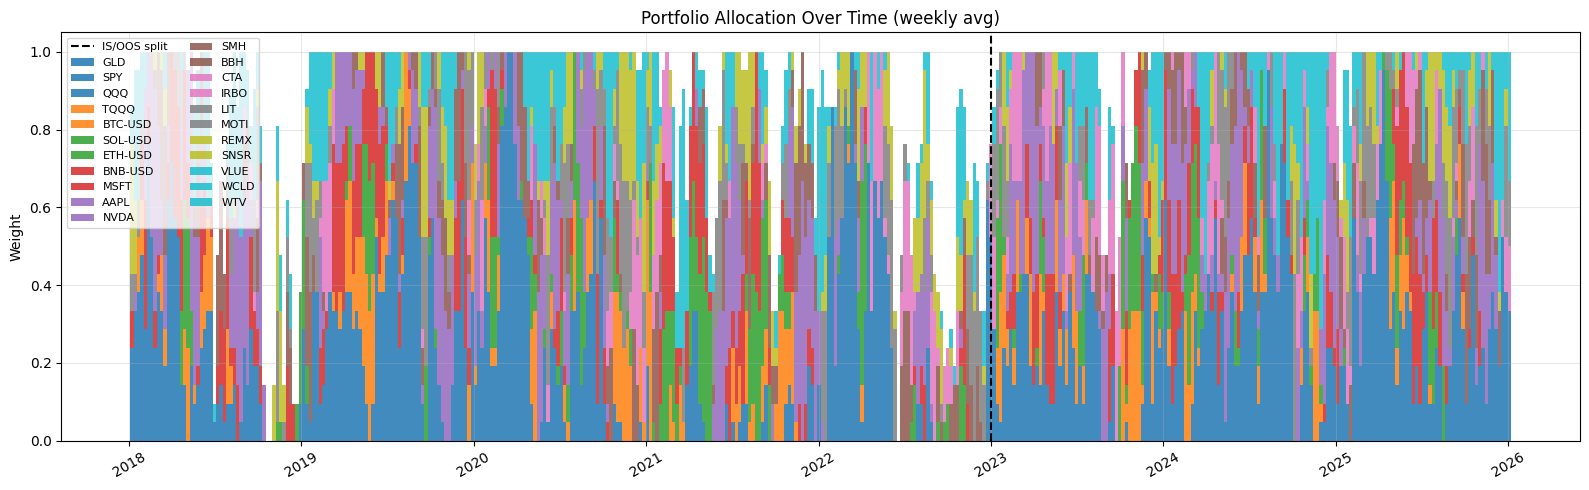


═══ Average Allocation by Asset ═══


GLD        16.9%
AAPL        7.2%
MSFT        5.1%
WTV         5.1%
NVDA        5.1%
REMX        4.1%
BTC-USD     4.0%
SPY         3.9%
MOTI        3.7%
QQQ         3.6%
BBH         3.4%
LIT         3.4%
ETH-USD     3.2%
BNB-USD     3.0%
SMH         3.0%
CTA         2.9%
VLUE        2.8%
SOL-USD     2.4%
WCLD        2.1%
TQQQ        2.0%
IRBO        2.0%
SNSR        1.9%
Name: Avg Weight, dtype: object


═══ Cash Allocation ═══
  Days in partial/full cash: 16.5%


In [ ]:
# Cell 13 — Allocation Stacked Bar Chart
fig, ax = plt.subplots(figsize=(16, 5))

w_weekly = weights_df.resample('W').mean()
w_weekly = w_weekly.loc[w_weekly.index >= IS_START]

colors = plt.cm.tab10(np.linspace(0, 1, len(weights_df.columns)))
bottom = np.zeros(len(w_weekly))

for i, col in enumerate(weights_df.columns):
    vals = w_weekly[col].fillna(0).values
    ax.bar(w_weekly.index, vals, bottom=bottom,
           color=colors[i], label=col, width=7, alpha=0.85)
    bottom += vals

ax.axvline(pd.Timestamp(OOS_START), color='black', linestyle='--',
           linewidth=1.5, label='IS/OOS split')
ax.set_title('Portfolio Allocation Over Time (weekly avg)', fontsize=12)
ax.set_ylabel('Weight')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('\n═══ Average Allocation by Asset ═══')
avg_alloc = weights_df.mean().sort_values(ascending=False)
display(avg_alloc.map('{:.1%}'.format).rename('Avg Weight'))

print(f'\n═══ Cash Allocation ═══')
cash_pct = (weights_df.sum(axis=1) < 0.999).mean()
print(f'  Days in partial/full cash: {cash_pct:.1%}')

Building correlation-filtered portfolio weights...
Weight sum stats:
  Mean : 0.930
  Min  : 0.000
  Max  : 1.000
  % days fully invested : 88.1%
  % days in cash        : 2.5%

Rebalance events       : 435
Avg turnover per event : 113.3%

Correlation-filtered weights built ✓
═══ Original vs Correlation-Filtered ═══



,CAGR,Sharpe,MaxDD,Calmar,WinRate
Label,,,,,
Original (IS),0.5307,1.3155,-0.3836,1.3833,0.3959
Original (OOS),0.3429,1.3409,-0.2615,1.3115,0.3954
Corr-Filtered (IS),0.7116,1.6012,-0.3002,2.3701,0.4189
Corr-Filtered (OOS),0.5644,1.7043,-0.1872,3.0158,0.4228


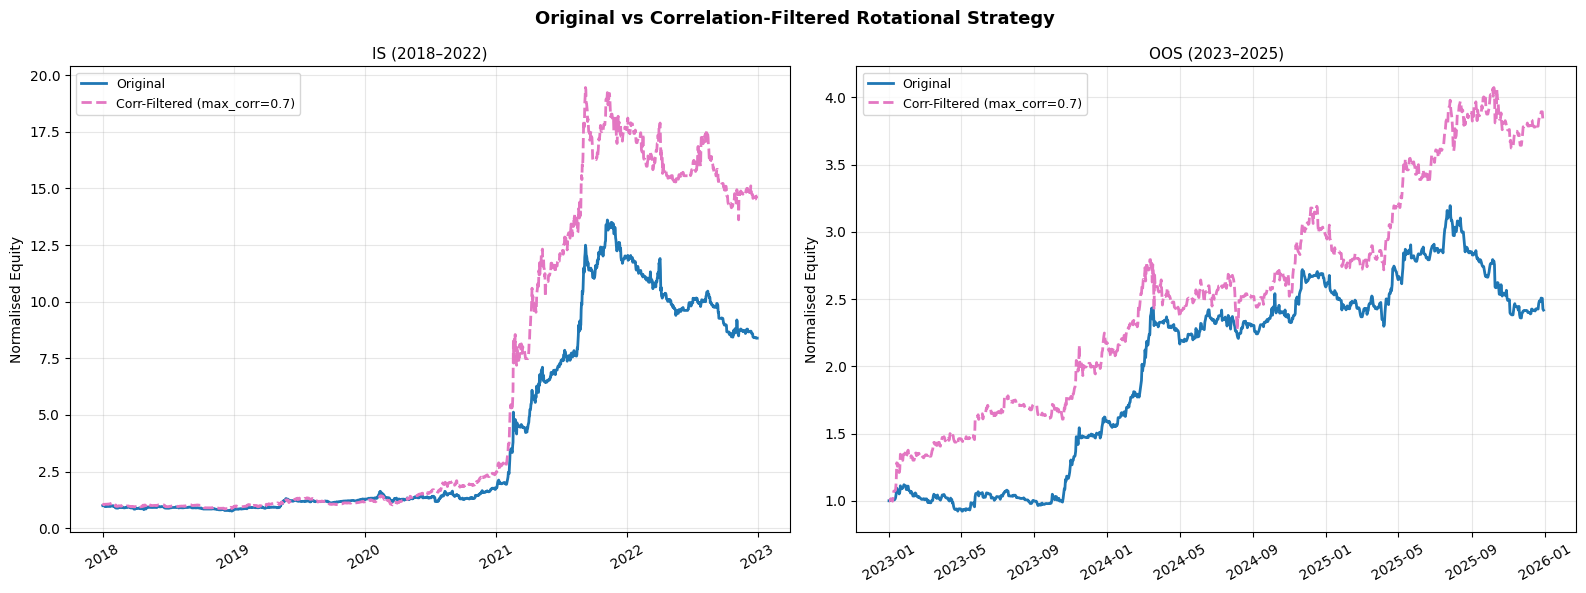

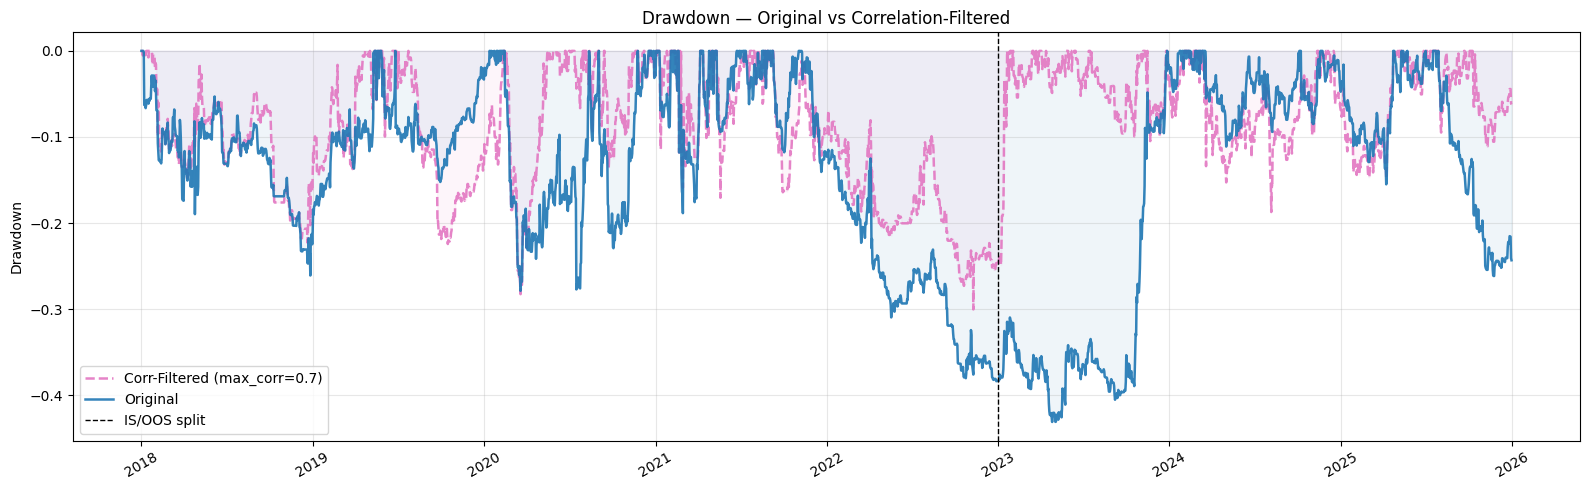

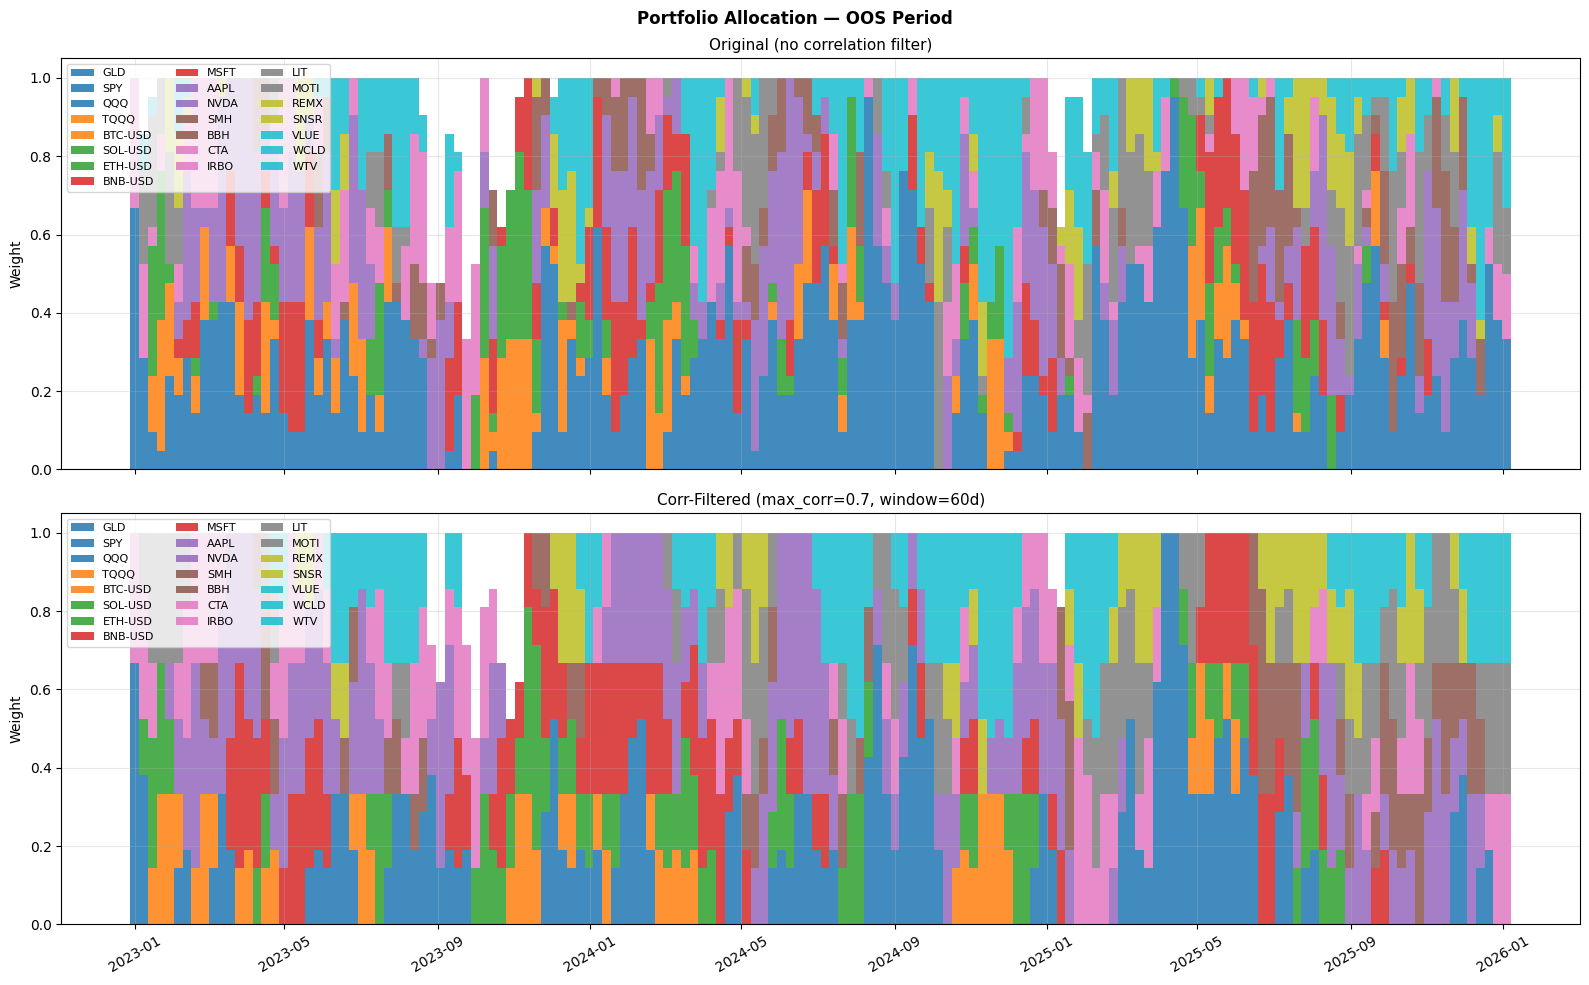

In [29]:
# Cell 14: CORRELATION FILTER
CORR_WINDOW = 60
MAX_CORR    = 0.70

def build_portfolio_weights_corr(rsi_ranks, all_positions, all_closes,
                                  top_n, safe_haven, tickers,
                                  rebalance_freq, max_corr, corr_window):
    common_idx = rsi_ranks.index
    pos_df = pd.DataFrame({
        t: all_positions[t].reindex(common_idx, fill_value=0)
        for t in tickers if t in all_positions
    })
    rank_df = rsi_ranks.reindex(columns=pos_df.columns)

    ret_df_local = pd.DataFrame({
        t: all_closes[t].reindex(common_idx).pct_change().fillna(0)
        for t in pos_df.columns if t in all_closes
    })

    weight_per_slot = 1.0 / top_n
    weights_corr_df = pd.DataFrame(0.0, index=common_idx, columns=pos_df.columns)
    risk_universe   = [t for t in pos_df.columns if t != safe_haven]

    rebalance_dates = set(
        pd.date_range(common_idx[0], common_idx[-1], freq=rebalance_freq)
        .map(lambda d: common_idx[common_idx <= d].max()
             if len(common_idx[common_idx <= d]) > 0 else pd.NaT)
    )
    rebalance_dates.discard(pd.NaT)

    current_weights = pd.Series(0.0, index=pos_df.columns)

    # Convert index to positional for leak-free slicing
    idx_map = {date: i for i, date in enumerate(common_idx)}

    for date in common_idx:
        if date in rebalance_dates:
            ranks_today = rank_df.loc[date]
            pos_today   = pos_df.loc[date]
            new_weights = pd.Series(0.0, index=pos_df.columns)

            # FIX: use strictly past returns — exclude today's row (idx_map[date])
            # so the correlation window contains only returns[0 : idx_map[date]],
            # i.e. everything up to and including yesterday.
            past_idx    = idx_map[date]
            hist        = ret_df_local.iloc[max(0, past_idx - corr_window) : past_idx]
            corr_matrix = hist.corr()

            top_ranked = ranks_today[
                ranks_today.index.isin(risk_universe) &
                (ranks_today <= top_n * 3)
            ].sort_values().index.tolist()

            eligible_risk = [t for t in top_ranked if pos_today.get(t, 0) == 1]

            selected = []
            for candidate in eligible_risk:
                if len(selected) >= top_n:
                    break
                if len(selected) == 0:
                    selected.append(candidate)
                    continue
                corrs = []
                for already_in in selected:
                    try:
                        c = abs(corr_matrix.loc[candidate, already_in])
                    except KeyError:
                        c = 0.0
                    corrs.append(c)
                if max(corrs) < max_corr:
                    selected.append(candidate)

            slots_filled = 0
            for asset in selected:
                new_weights[asset] = weight_per_slot
                slots_filled += 1

            remaining = top_n - slots_filled
            if remaining > 0 and safe_haven in pos_df.columns:
                if pos_today.get(safe_haven, 0) == 1:
                    new_weights[safe_haven] = remaining * weight_per_slot

            current_weights = new_weights

        weights_corr_df.loc[date] = current_weights

    row_sums = weights_corr_df.sum(axis=1)
    assert row_sums.max() <= 1.0 + 1e-9, \
        f'Weight sum exceeded 1.0! Max = {row_sums.max():.6f}'

    return weights_corr_df


print('Building correlation-filtered portfolio weights...')
weights_corr_df = build_portfolio_weights_corr(
    rsi_ranks, all_positions, all_closes,
    TOP_N, SAFE_HAVEN, TICKERS,
    REBALANCE_FREQ, MAX_CORR, CORR_WINDOW
)

net_ret_corr, gross_ret_corr, costs_corr, _ = build_portfolio_returns(
    weights_corr_df, all_closes, CRYPTO_TICKERS, TQQQ_DECAY_BPS_PER_DAY
)

is_mask_c  = (net_ret_corr.index >= IS_START)  & (net_ret_corr.index <= IS_END)
oos_mask_c = (net_ret_corr.index >= OOS_START) & (net_ret_corr.index <= OOS_END)

equity_corr_full = (1 + net_ret_corr).cumprod()
equity_corr_is   = (1 + net_ret_corr[is_mask_c]).cumprod()
equity_corr_oos  = (1 + net_ret_corr[oos_mask_c]).cumprod()

weight_sums_corr = weights_corr_df.sum(axis=1)
print(f'Weight sum stats:')
print(f'  Mean : {weight_sums_corr.mean():.3f}')
print(f'  Min  : {weight_sums_corr.min():.3f}')
print(f'  Max  : {weight_sums_corr.max():.3f}')
print(f'  % days fully invested : {(weight_sums_corr >= 0.999).mean():.1%}')
print(f'  % days in cash        : {(weight_sums_corr < 0.001).mean():.1%}')

turnovers_corr      = weights_corr_df.diff().abs().sum(axis=1)
rebalance_days_corr = turnovers_corr[turnovers_corr > 0.001]
print(f'\nRebalance events       : {len(rebalance_days_corr)}')
print(f'Avg turnover per event : {rebalance_days_corr.mean():.1%}')
print('\nCorrelation-filtered weights built ✓')

orig_is  = full_metrics(net_ret[is_mask],        equity_is,       label='Original (IS)')
orig_oos = full_metrics(net_ret[oos_mask],        equity_oos,      label='Original (OOS)')
corr_is  = full_metrics(net_ret_corr[is_mask_c], equity_corr_is,  label='Corr-Filtered (IS)')
corr_oos = full_metrics(net_ret_corr[oos_mask_c],equity_corr_oos, label='Corr-Filtered (OOS)')

comparison_df = pd.DataFrame([orig_is, orig_oos, corr_is, corr_oos])
print('═══ Original vs Correlation-Filtered ═══\n')
display(comparison_df.set_index('Label')[['CAGR','Sharpe','MaxDD','Calmar','WinRate']])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Original vs Correlation-Filtered Rotational Strategy',
             fontsize=13, fontweight='bold')

for ax, (phase, is_m, oos_m) in zip(axes, [
    ('IS (2018–2022)',  is_mask,  is_mask_c),
    ('OOS (2023–2025)', oos_mask, oos_mask_c),
]):
    orig_eq = (1 + net_ret[is_m if 'IS' in phase else oos_m]).cumprod()
    corr_eq = (1 + net_ret_corr[is_m if 'IS' in phase else oos_mask_c]).cumprod()
    orig_n  = orig_eq / orig_eq.iloc[0]
    corr_n  = corr_eq / corr_eq.iloc[0]
    ax.plot(orig_n.index, orig_n.values,
            color='#1f77b4', linewidth=2.0, label='Original')
    ax.plot(corr_n.index, corr_n.values,
            color='#e377c2', linewidth=2.0, linestyle='--',
            label=f'Corr-Filtered (max_corr={MAX_CORR})')
    ax.set_title(phase, fontsize=11)
    ax.set_ylabel('Normalised Equity')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

PLOT_START = pd.Timestamp(IS_START)

fig, ax = plt.subplots(figsize=(16, 5))
for eq, ret, color, label, ls in [
    (equity_corr_full, net_ret_corr, '#e377c2',
     f'Corr-Filtered (max_corr={MAX_CORR})', '--'),
    (equity_full,      net_ret,      '#1f77b4', 'Original', '-'),
]:
    eq = eq[eq.index >= PLOT_START]
    eq_n = eq / eq.iloc[0]
    dd   = eq_n / eq_n.cummax() - 1
    ax.plot(dd.index, dd.values, color=color,
            linewidth=1.8, linestyle=ls, label=label, alpha=0.9)
    ax.fill_between(dd.index, dd.values, 0, color=color, alpha=0.07)

ax.axvline(pd.Timestamp(OOS_START), color='black',
           linestyle='--', linewidth=1.0, label='IS/OOS split')
ax.set_title('Drawdown — Original vs Correlation-Filtered', fontsize=12)
ax.set_ylabel('Drawdown')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Portfolio Allocation — OOS Period', fontsize=12, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, len(weights_df.columns)))
for ax, (wdf, title) in zip(axes, [
    (weights_df,      'Original (no correlation filter)'),
    (weights_corr_df, f'Corr-Filtered (max_corr={MAX_CORR}, window={CORR_WINDOW}d)'),
]):
    w_oos  = wdf[oos_mask].resample('W').mean()
    bottom = np.zeros(len(w_oos))
    for i, col in enumerate(wdf.columns):
        vals = w_oos[col].fillna(0).values
        ax.bar(w_oos.index, vals, bottom=bottom,
               color=colors[i], label=col, width=7, alpha=0.85)
        bottom += vals
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Weight')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper left', fontsize=8, ncol=3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()